import relevant libraries
Read Data
Clean and Process the Data
Selective View (Select columns)
Do Calculation
Do Visualization
Export (Data, Plot or both)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt 

Data = pd.read_csv('XY Data Full.txt', sep='\t')
Data 

,UID,WELLNAME,ALIAS,XCOORD,YCOORD,BOTTOMX,BOTTOMY,KBELEV,TDEPTH,CDATE,...,Status,Zone,Flow_Station,UID.2,PAY,POROSITY,SW,RFo,RFg,SSMA_TimeStamp
0,ACL1010,ACL 10-10,10-10,456103.49,5797256.280,456103.49,5797256.280,2373.031,3215.223,1993-08-13 00:00:00,...,GAS,VI,NE,ACL1010,NaN,NaN,NaN,NaN,NaN,0x0000000000005ECF
1,BTEL1436,BTEL 14-36,14-36,459156.31,5803984.220,459156.31,5803984.220,2401.575,3359.580,1995-01-28 00:00:00,...,P&A,III,N,BTEL1436,NaN,NaN,NaN,NaN,NaN,0x0000000000005ED0
2,HOGL1132,HOGL 11-32,11-32,465255.40,5789000.000,465255.40,5789000.000,2463.583,3197.178,1980-09-06 00:00:00,...,OIL,III,TB0539,HOGL1132,12.6,0.27,0.14,NaN,0.34,0x0000000000005ED1
3,HOGL1228,HOGL 12-28,12-28,453821.84,5802019.870,453821.84,5802019.870,2364.501,3218.504,2008-03-14 00:00:00,...,GAS,V,N,HOGL1228,NaN,6.00,0.25,0.15,NaN,0x0000000000005ED2
4,HOGL1528,HOGL 15-28,15-28,454442.92,5802794.200,454441.31,5802656.830,2367.782,3280.840,2007-09-20 00:00:00,...,GAS,IVA,N,HOGL1528,NaN,36.60,0.28,0.16,NaN,0x0000000000005ED3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,PVEC_0731,PVEC 7-31,C0/07-31,469836.28,5795565.375,469836.28,5795565.375,2454.724,3313.648,1993-05-23 00:00:00,...,OIL,III,TB0532,PVEC_0731,26.4,0.27,0.15,NaN,0.34,0x0000000000005F23
84,PVEC2_0131,PVEC2 1-31,C2/01-31,468843.80,5795773.275,468843.80,5795773.275,2472.113,3187.664,1989-10-14 00:00:00,...,OIL,III,TB0532,PVEC2_0131,36.8,0.25,0.16,NaN,0.34,0x0000000000005F24
85,PVED_0231,PVED 2-31,D0/02-31,469836.72,5797000.000,469836.72,5797000.000,2447.178,3198.819,1993-05-15 00:00:00,...,OIL,IVA,TB0532,PVED_0231,20.4,0.26,0.17,NaN,0.34,0x0000000000005F25
86,PVED_0731,PVED 7-31,D0/07-31,467840.99,5793200.163,467840.99,5793200.163,2468.176,3193.570,1989-06-09 00:00:00,...,OIL,III,TB0532,PVED_0731,11.8,0.27,0.18,NaN,0.34,0x0000000000005F26


In [4]:
# Selective data reading
# if you want to read all columns use Data.columns
Data.columns

Index(['UID', 'WELLNAME', 'ALIAS', 'XCOORD', 'YCOORD', 'BOTTOMX', 'BOTTOMY',
       'KBELEV', 'TDEPTH', 'CDATE', 'ONPRODDATE', 'ONINJDATE', 'PerfTop',
       'PerfBot', 'Perfed_Ft', 'Recompletion_Date', 'UID.1', 'Geometry',
       'Field', 'Pool', 'Operator', 'Status', 'Zone', 'Flow_Station', 'UID.2',
       'PAY', 'POROSITY', 'SW', 'RFo', 'RFg', 'SSMA_TimeStamp'],
      dtype='object')

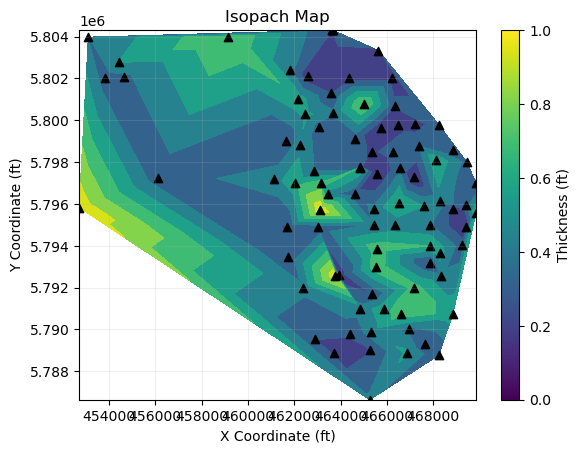

In [32]:
x = Data['XCOORD']
y = Data['YCOORD']
z = Data['TDEPTH']
plt.tricontourf(x, y, z)
plt.scatter(x, y, c='black', marker='^')
plt.title('Isopach Map')
plt.grid(alpha=0.2)
plt.xlabel('X Coordinate (ft)')
plt.ylabel('Y Coordinate (ft)')
plt.colorbar(label='Thickness (ft)')
plt.savefig('Isopach Map.pdf')

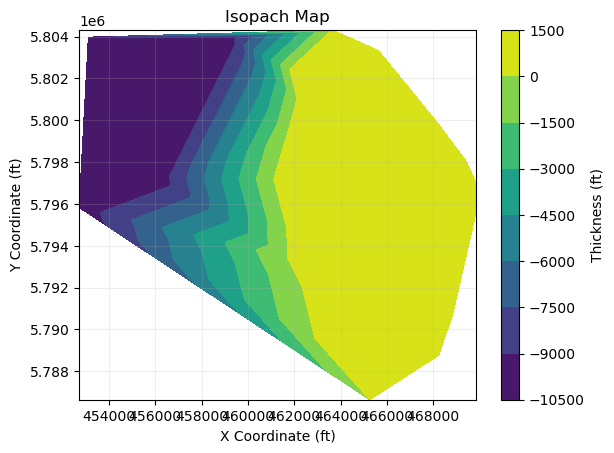

In [25]:
x = Data['XCOORD']
y = Data['YCOORD']
z = Data['PAY']
plt.tricontourf(x, y, z)
plt.title('Isopach Map')
plt.grid(alpha=0.2)
plt.xlabel('X Coordinate (ft)')
plt.ylabel('Y Coordinate (ft)')
plt.colorbar(label='Thickness (ft)')

In [33]:
# cleaning data, filling null values with 
avg = Data['PAY'].mean()
Data['PAY'].fillna(avg, inplace=True)
Data['PAY']

0    -9999.0
1    -9999.0
2       12.6
3    -9999.0
4    -9999.0
       ...  
83      26.4
84      36.8
85      20.4
86      11.8
87   -9999.0
Name: PAY, Length: 88, dtype: float64

In [34]:
# Get statistics on well inventory
Data['Pool'].value_counts() # Count of wells in each pool

Pool
BLM B          81
VK 1            2
LOD UND         2
ELIS LL         1
UND POOL        1
U-MNVL C10C     1
Name: count, dtype: int64

In [35]:
Data['Operator'].value_counts()

Operator
HOGL    72
PVEL    12
AVAB     2
APCL     2
Name: count, dtype: int64

In [36]:
Data['Status'].value_counts()

Status
OIL     75
GAS      5
WINJ     5
P&A      3
Name: count, dtype: int64

<Axes: xlabel='Pool'>

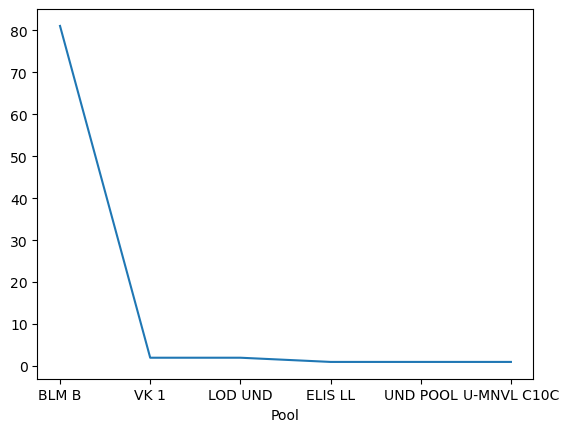

In [37]:
Data['Pool'].value_counts().plot()

In [40]:
import plotly.express as px
# 3 inputs are required in plotly
fig = px.scatter(Data, x='XCOORD', y='YCOORD', color='Zone', symbol='Status')
fig

In [43]:
Data
sw = 0.21
pay = 30
poro = 0.18
Data['SW'] = Data['SW'].fillna(sw)
Data['POROSITY'] = Data['POROSITY'].fillna(poro)   
Data.to_excel('Cleaned Field Data.xlsx')  
Data   
# Start cleaning data

,UID,WELLNAME,ALIAS,XCOORD,YCOORD,BOTTOMX,BOTTOMY,KBELEV,TDEPTH,CDATE,...,Status,Zone,Flow_Station,UID.2,PAY,POROSITY,SW,RFo,RFg,SSMA_TimeStamp
0,ACL1010,ACL 10-10,10-10,456103.49,5797256.280,456103.49,5797256.280,2373.031,3215.223,1993-08-13 00:00:00,...,GAS,VI,NE,ACL1010,-9999.0,0.18,0.21,NaN,NaN,0x0000000000005ECF
1,BTEL1436,BTEL 14-36,14-36,459156.31,5803984.220,459156.31,5803984.220,2401.575,3359.580,1995-01-28 00:00:00,...,P&A,III,N,BTEL1436,-9999.0,0.18,0.21,NaN,NaN,0x0000000000005ED0
2,HOGL1132,HOGL 11-32,11-32,465255.40,5789000.000,465255.40,5789000.000,2463.583,3197.178,1980-09-06 00:00:00,...,OIL,III,TB0539,HOGL1132,12.6,0.27,0.14,NaN,0.34,0x0000000000005ED1
3,HOGL1228,HOGL 12-28,12-28,453821.84,5802019.870,453821.84,5802019.870,2364.501,3218.504,2008-03-14 00:00:00,...,GAS,V,N,HOGL1228,-9999.0,6.00,0.25,0.15,NaN,0x0000000000005ED2
4,HOGL1528,HOGL 15-28,15-28,454442.92,5802794.200,454441.31,5802656.830,2367.782,3280.840,2007-09-20 00:00:00,...,GAS,IVA,N,HOGL1528,-9999.0,36.60,0.28,0.16,NaN,0x0000000000005ED3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,PVEC_0731,PVEC 7-31,C0/07-31,469836.28,5795565.375,469836.28,5795565.375,2454.724,3313.648,1993-05-23 00:00:00,...,OIL,III,TB0532,PVEC_0731,26.4,0.27,0.15,NaN,0.34,0x0000000000005F23
84,PVEC2_0131,PVEC2 1-31,C2/01-31,468843.80,5795773.275,468843.80,5795773.275,2472.113,3187.664,1989-10-14 00:00:00,...,OIL,III,TB0532,PVEC2_0131,36.8,0.25,0.16,NaN,0.34,0x0000000000005F24
85,PVED_0231,PVED 2-31,D0/02-31,469836.72,5797000.000,469836.72,5797000.000,2447.178,3198.819,1993-05-15 00:00:00,...,OIL,IVA,TB0532,PVED_0231,20.4,0.26,0.17,NaN,0.34,0x0000000000005F25
86,PVED_0731,PVED 7-31,D0/07-31,467840.99,5793200.163,467840.99,5793200.163,2468.176,3193.570,1989-06-09 00:00:00,...,OIL,III,TB0532,PVED_0731,11.8,0.27,0.18,NaN,0.34,0x0000000000005F26
